# Running gait signal core — end-to-end walkthrough

One subject, all four stages, with plots at every stage.

**Dataset**: MotionSense `A_DeviceMotion_data`, jog trials (9 and 16), 24 subjects,
iPhone 6s in the front trouser pocket, 50 Hz nominal.

**What this dataset is being used for**: developing and stress-testing algorithms that
must be *placement-* and *rate-agnostic*. The phone is at the pocket and the rate is
50 Hz; the production target is the lower back at 100 Hz fused / 200 Hz raw. Anywhere a
stage quietly depends on the pocket or on 50 Hz, this notebook is built to surface it
rather than hide it.

**Setup**: run `python scripts/fetch_data.py` once, then set `MOTIONSENSE_ROOT` (the
script prints the value) — or leave it unset and the loader will find `./data/motion-sense/data`.

In [1]:
import os, sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import loader, orientation, steps, lateral, pipeline, plotting, dsp

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# Everything downstream takes the rate as a parameter. Change this one line
# and the whole notebook runs at another rate; nothing hardcodes 50 Hz.
FS_HZ = loader.DEFAULT_FS_HZ
SUBJECT, TRIAL = 1, 9

print(f"dataset root: {loader.resolve_data_root()}")
print(f"sample rate : {FS_HZ} Hz (a parameter, not a constant)")

dataset root: /home/user/motion-sense/data
sample rate : 50.0 Hz (a parameter, not a constant)


---
## Stage 1 — loader and explorer

The layout below was read out of the dataset's own README and then verified on disk,
not assumed: `A_DeviceMotion_data/<activity>_<trial>/sub_<subject>.csv`, jog = trials
9 and 16, 24 subjects each.

In [2]:
trial = loader.load_trial("jog", TRIAL, SUBJECT, fs_hz=FS_HZ)
print(trial.ident, "->", trial.path)
print(f"{trial.n_samples} samples @ {trial.fs_hz:g} Hz = {trial.duration_s:.2f} s")
trial.df.head()

jog_9/sub_1 -> /home/user/motion-sense/data/A_DeviceMotion_data/jog_9/sub_1.csv
4861 samples @ 50 Hz = 97.22 s


,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z
t_s,,,,,,,,,,,,
0.00,3.058304,-1.227988,2.570999,0.027964,0.941814,0.334969,0.160508,-1.386834,-0.749713,0.204199,0.172657,-0.801048
0.02,3.075964,-1.225818,2.615277,0.022178,0.941083,0.337448,-0.217198,-0.612402,-0.682841,0.089974,-0.373914,-0.506332
0.04,3.103364,-1.235013,2.651791,0.012594,0.944152,0.329269,0.663253,-0.498534,-0.620223,0.260127,-0.364364,-0.781249
0.06,3.109208,-1.244901,2.678484,0.010366,0.947364,0.319989,0.458100,-1.202168,-0.304561,0.584253,-0.922813,-0.285169
0.08,3.074214,-1.263514,2.661371,0.020364,0.953159,0.301783,1.347809,-0.550578,0.610944,0.626501,-1.045978,-0.063884


### The time index is reconstructed, not measured

The CSVs carry an integer row counter and twelve signal columns. **There is no timestamp
column anywhere in this dataset.** The time index is therefore `arange(n) / fs_hz` — a
uniform grid we impose. The consequence is stated in the integrity record and it is not
small: dropped samples, clock jitter and rate drift are all *undetectable* here. A 97.2 s
trial and a 100 s trial that lost 140 samples are the same file to us.

In [3]:
integrity = trial.integrity
for k in ["n_samples", "duration_s", "has_timestamp_column",
          "timestamp_irregularities_detectable", "index_contiguous", "index_gaps",
          "n_nan", "n_duplicate_rows", "longest_flatline_s", "gravity_mag_mean",
          "gravity_mag_std", "clean", "problems"]:
    print(f"{k:38s} {integrity[k]}")

n_samples                              4861
duration_s                             97.22
has_timestamp_column                   False
timestamp_irregularities_detectable    False
index_contiguous                       True
index_gaps                             0
n_nan                                  0
n_duplicate_rows                       0
longest_flatline_s                     0.02
gravity_mag_mean                       0.9999999981012366
gravity_mag_std                        2.9194033814537887e-07
clean                                  True
problems                               


Note `gravity_mag_mean` ≈ 1.000000 with a standard deviation of ~1e-6. That is *not*
evidence the sensor fusion is tracking well — CoreMotion normalises the gravity vector as
part of its output, so unit magnitude is true by construction. It is a file-corruption
check and nothing more.

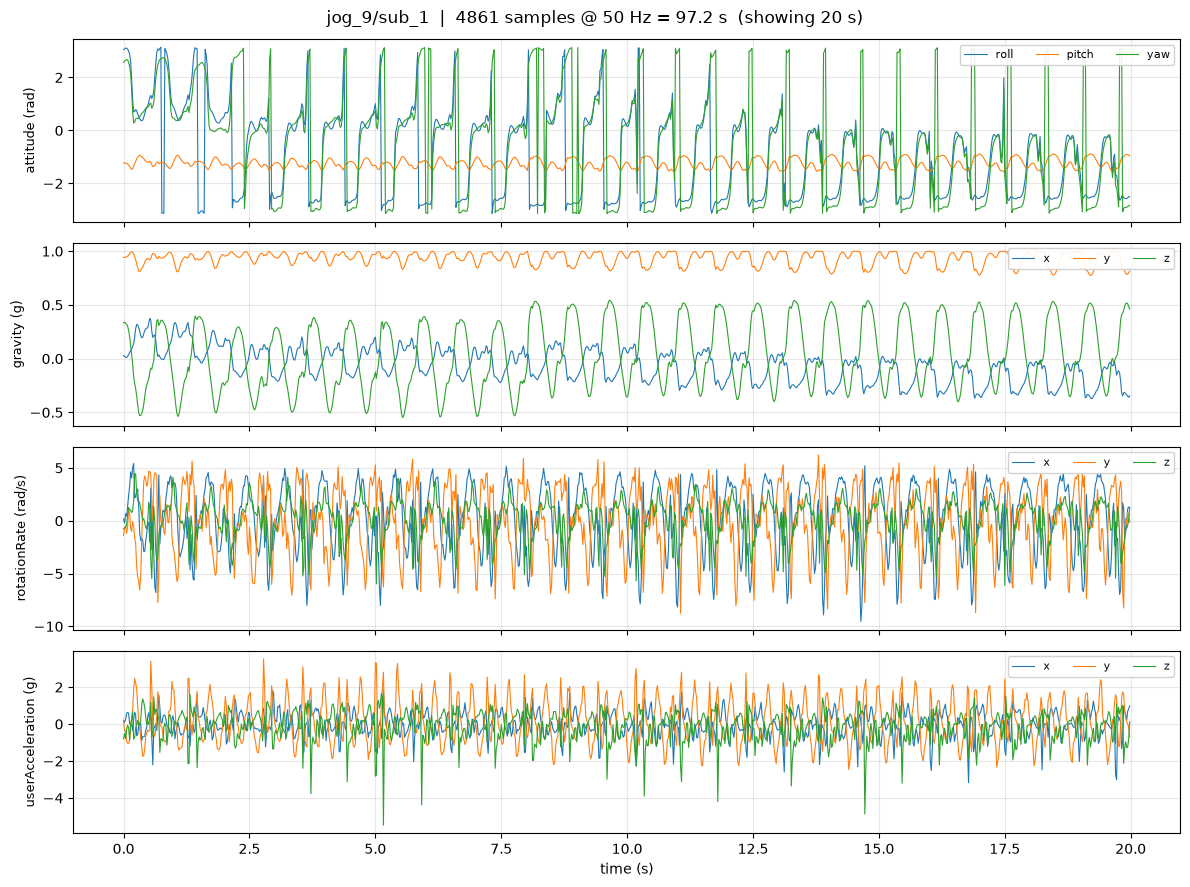

In [4]:
fig = plotting.plot_raw_signals(trial, seconds=20)
plt.show()

### Summary across all 48 jog trials

In [5]:
summary = loader.summarize_trials("jog", fs_hz=FS_HZ)
print(f"{len(summary)} trials | all clean: {summary['clean'].all()} | "
      f"any timestamps: {summary['has_timestamp_column'].any()}")
summary.groupby("trial")[["n_samples", "duration_s", "user_accel_rms_g",
                          "rotation_rate_rms_rad_s"]].describe().T.round(3)

48 trials | all clean: True | any timestamps: False


trial                                9         16
n_samples               count    24.000    24.000
                        mean   4346.958  1246.000
                        std     701.976   295.868
                        min    2843.000   765.000
                        25%    3883.750  1018.000
                        50%    4465.500  1226.500
                        75%    4825.250  1452.250
                        max    5535.000  1952.000
duration_s              count    24.000    24.000
                        mean     86.939    24.920
                        std      14.040     5.917
                        min      56.860    15.300
                        25%      77.675    20.360
                        50%      89.310    24.530
                        75%      96.505    29.045
                        max     110.700    39.040
user_accel_rms_g        count    24.000    24.000
                        mean      1.705     1.708
                        std       0.367     0.350
                        min       1.090     1.070
                        25%       1.459     1.523
                        50%       1.729     1.750
                        75%       1.880     1.968
                        max       2.526     2.394
rotation_rate_rms_rad_s count    24.000    24.000
                        mean      3.859     3.834
                        std       1.021     1.045
                        min       2.001     1.754
                        25%       3.141     3.126
                        50%       4.026     4.005
                        75%       4.664     4.459
                        max       5.780     5.688

In [6]:
cols = ["trial", "subject", "n_samples", "duration_s", "index_contiguous", "n_nan",
        "longest_flatline_s", "gravity_mag_mean", "user_accel_rms_g", "clean"]
summary[cols].head(12)

,trial,subject,n_samples,duration_s,index_contiguous,n_nan,longest_flatline_s,gravity_mag_mean,user_accel_rms_g,clean
0,9,1,4861,97.22,True,0,0.02,1.000000,1.620847,True
1,9,2,4966,99.32,True,0,0.02,0.999996,1.743837,True
2,9,3,4753,95.06,True,0,0.02,0.999998,1.337232,True
3,9,4,5294,105.88,True,0,0.02,0.999996,1.804884,True
4,9,5,3558,71.16,True,0,0.02,0.999993,1.217382,True
5,9,6,4343,86.86,True,0,0.02,0.999997,2.111468,True
6,9,7,4549,90.98,True,0,0.02,0.999998,1.458848,True
7,9,8,4247,84.94,True,0,0.02,0.999982,1.141631,True
8,9,9,3847,76.94,True,0,0.02,0.999996,2.054177,True
9,9,10,4397,87.94,True,0,0.02,0.999995,1.720941,True


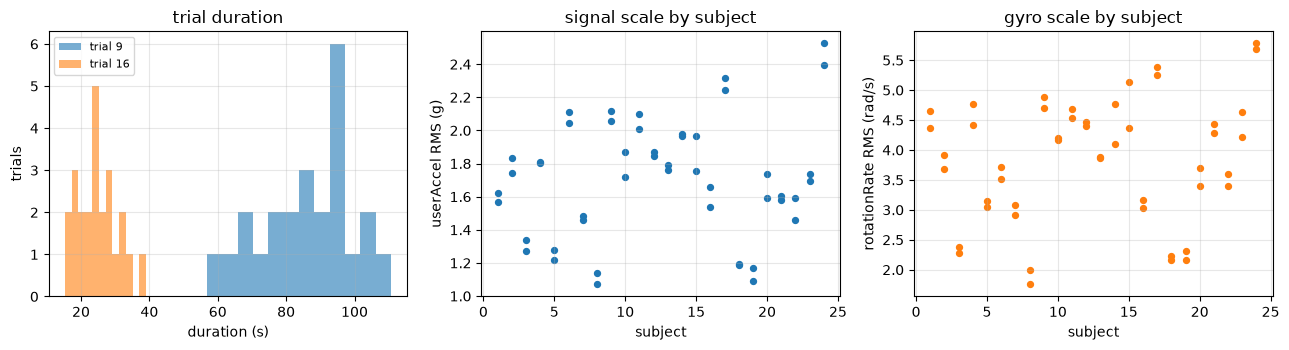

In [7]:
fig = plotting.plot_trial_summary(summary)
plt.show()

**Stage 1 findings.** All 48 files are clean: contiguous row index, zero NaN/Inf, no
duplicate rows, no flatlines. Durations run 15.3–110.7 s (trial 16 short, trial 9 long).
The only irregularity worth reporting is the one we cannot measure: there are no
timestamps, so no sampling irregularity of any kind is observable.

---
## Stage 1b — trimming handling transients

The protocol had participants start the app, pocket the phone, run, then stop and retrieve
it. Both ends of every trial contain handling that is not running, and it has to go before
anything is measured. The detector runs on acceleration *magnitude*, which is
rotation-invariant, so this step is independent of stage 2.

kept 95.0 s of 97.2 s  (cut 0.0 s from the start, 2.2 s from the end)


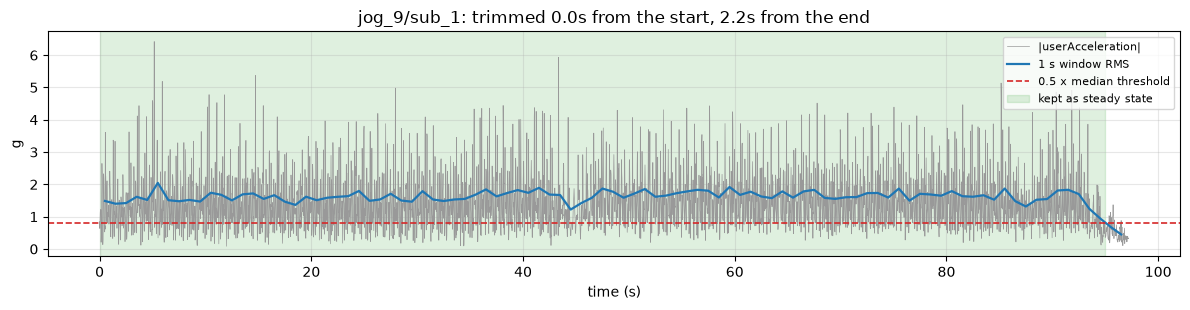

In [8]:
result = pipeline.run_trial("jog", TRIAL, SUBJECT, fs_hz=FS_HZ)
seg = result["segment"]
print(f"kept {result['steady_seconds']:.1f} s of {trial.duration_s:.1f} s  "
      f"(cut {seg['trimmed_start_s']:.1f} s from the start, {seg['trimmed_end_s']:.1f} s from the end)")
fig = plotting.plot_steady_state(result)
plt.show()

---
## Stage 2 — orientation resolution

The phone sits at an unknown, arbitrary rotation. We recover:

- **vertical** from the gravity vector (`up = -gravity_hat`);
- **forward** from the dominant horizontal acceleration axis during steady motion;
- **mediolateral** from the cross product (`up × forward`, so +ML points *left*).

Two forward estimators are available. `pca` is the literal broadband principal component
the spec describes. `step_band` restricts to a narrow band around the step frequency,
because braking and propulsion happen once per step and so concentrate fore-aft energy at
the step fundamental. Both are placement-agnostic in formulation; they differ sharply in
conditioning.

In [9]:
frame = result["frame"]
print("up          ", np.round(frame.up, 4))
print("forward     ", np.round(frame.forward, 4))
print("mediolateral", np.round(frame.mediolateral, 4), " (+ = runner's left)")
print("\nR (rows = forward, ML, up):\n", np.round(frame.rotation, 4))
print()
for k, v in frame.diagnostics.items():
    print(f"{k:38s} {round(v, 4) if isinstance(v, float) else v}")

up           [ 0.3087 -0.9344  0.1777]
forward      [-0.6569 -0.0743  0.7503]
mediolateral [-0.6879 -0.3484 -0.6368]  (+ = runner's left)

R (rows = forward, ML, up):
 [[-0.6569 -0.0743  0.7503]
 [-0.6879 -0.3484 -0.6368]
 [ 0.3087 -0.9344  0.1777]]

forward_method                         step_band
forward_eigenvalue_ratio               9.307
forward_well_conditioned               True
f_step_hz_used                         2.7359
forward_sign_flipped                   True
forward_braking_effect_size            0.2645
forward_sign_confident                 True
forward_sign_split_half_consistent     True
orthonormal_residual                   0.0
right_handed                           True


In [10]:
# Conditioning of the two forward estimators, on this trial.
accel = trial.user_accel[seg["start"]:seg["stop"]]
gravity = trial.gravity[seg["start"]:seg["stop"]]
up = orientation.vertical_axis(gravity)
for method in ("pca", "step_band"):
    est = orientation.forward_axis(accel, up, FS_HZ, method=method)
    print(f"{method:10s} eigenvalue ratio {est['eigenvalue_ratio']:7.2f}   "
          f"well conditioned: {est['well_conditioned']}")

pca        eigenvalue ratio    2.59   well conditioned: False
step_band  eigenvalue ratio    9.31   well conditioned: True


### Does the frame hold still?

Two independent measurements: how far instantaneous vertical wanders from trial-mean
vertical, and how much the forward axis moves when re-estimated on overlapping windows.

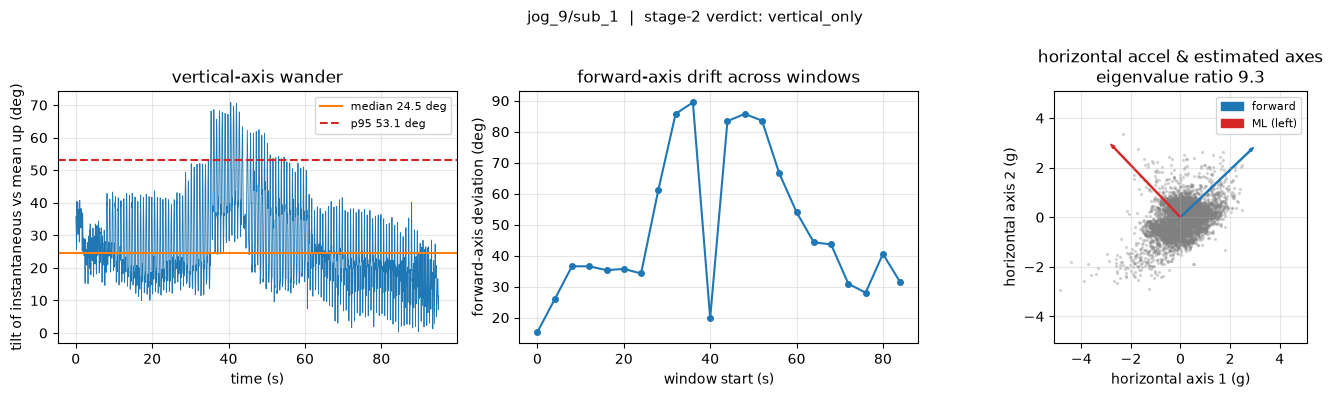

vertical_tilt_median_deg         24.51
vertical_tilt_p95_deg            53.1
vertical_tilt_max_deg            70.82
forward_drift_median_deg         38.59
forward_drift_p95_deg            85.79
frame_static_valid               False


In [11]:
fig = plotting.plot_frame(result)
plt.show()

stab = result["verify"]["stability"]
for k in ["vertical_tilt_median_deg", "vertical_tilt_p95_deg", "vertical_tilt_max_deg",
          "forward_drift_median_deg", "forward_drift_p95_deg", "frame_static_valid"]:
    print(f"{k:32s} {round(stab[k], 2) if isinstance(stab[k], float) else stab[k]}")

This is the first place the pocket asserts itself. The vertical axis wanders by tens of
degrees *within* the trial, because the thigh swings relative to the trunk. A single
trial-constant rotation is therefore wrong for most of every stride. That is why the
default frame mode is `tracking`: `up` is taken from instantaneous gravity at every sample
and the forward axis is re-projected into each sample's horizontal plane. The formulation
assumes nothing about placement — it simply stops assuming the sensor is rigid with the
trunk.

### Proving it worked: periodic footstrike structure

The vertical channel should show the footstrike pattern. We check the spectrum for a
dominant peak in a plausible step band, and the autocorrelation for a return at the gait
period.

An important subtlety: the test is applied at the **stride** lag (two step periods), not
the step lag. Gait's true repeat period is the stride — the two legs are not required to
produce identical waveforms. The step-lag autocorrelation is still reported, as a
*symmetry index*, because how far it falls below the stride value is itself informative.

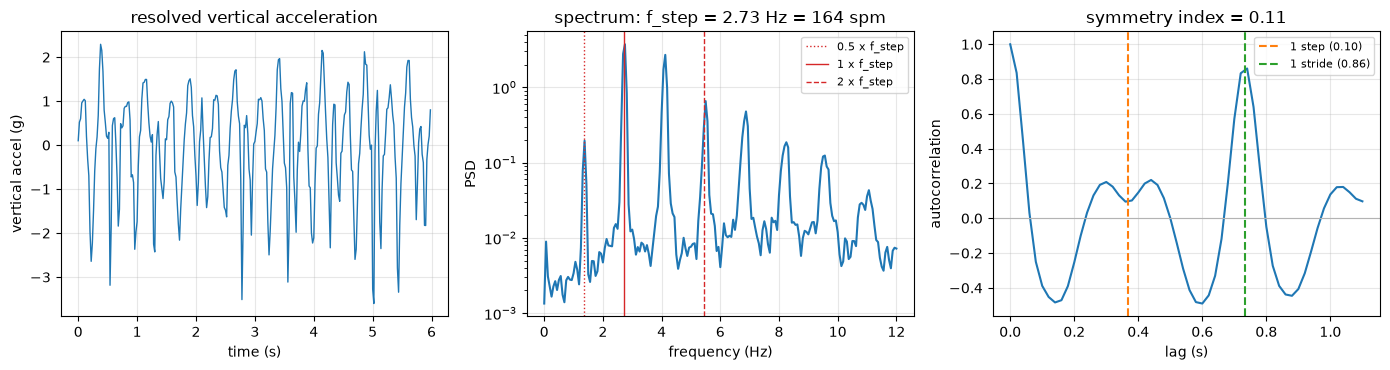

f_step_hz                      2.729
implied_cadence_spm            163.742
fundamental_power_fraction     0.393
second_harmonic_ratio          0.205
stride_subharmonic_ratio       0.043
step_regularity                0.096
stride_regularity              0.861
step_symmetry_index            0.111
periodicity_ok                 True


In [12]:
fig = plotting.plot_vertical_verification(result)
plt.show()

per = result["verify"]["periodicity"]
for k in ["f_step_hz", "implied_cadence_spm", "fundamental_power_fraction",
          "second_harmonic_ratio", "stride_subharmonic_ratio",
          "step_regularity", "stride_regularity", "step_symmetry_index", "periodicity_ok"]:
    print(f"{k:30s} {round(per[k], 3) if isinstance(per[k], float) else per[k]}")

### The stage-2 verdict, stated plainly

`verify_frame` returns one of three verdicts, and refuses to round `vertical_only` up to
`ok`:

- **`ok`** — every check passed.
- **`vertical_only`** — the vertical axis is sound and periodic, but the horizontal split
  is not supported by evidence. Downstream code may use vertical acceleration and must not
  use forward/ML.
- **`failed`** — the vertical axis itself produced no periodic footstrike signal.

In [13]:
v = result["verify"]
print("VERDICT:", v["verdict"].upper())
for r in v["reasons"]:
    print("  -", r)
print()
print("mediolateral cross-check:")
for k, val in v["mediolateral_check"].items():
    print(f"  {k:34s} {round(val, 2) if isinstance(val, float) else val}")

VERDICT: VERTICAL_ONLY
  - step-rate and stride-rate horizontal axes are 11 deg apart, not ~90 deg: mediolateral axis is unverified
  - NOTE (not a failure): vertical wanders 53 deg (p95) within the trial, so a trial-constant rotation would be invalid here; tracking mode is in use, which removes that error

mediolateral cross-check:
  step_stride_axis_angle_deg         10.72
  stride_axis_eigenvalue_ratio       32.32
  ml_independently_supported         False


The mediolateral cross-check is the one that fails, and it is worth understanding why it
is a real test rather than a formality.

At the trunk, biomechanics predicts a clean frequency separation: fore-aft acceleration is
driven by braking and propulsion once per **step**, while mediolateral acceleration is
driven by weight transfer to the stance side once per **stride**. So the horizontal axis
carrying most stride-rate power should sit ~90° from the axis carrying most step-rate
power. Measured here, the two axes are ~11° apart — nearly parallel. At the thigh both
harmonics ride on the same physical axis (the leg's swing plane), the prediction does not
hold, and the mediolateral axis is left as an unverified construction of the cross product.

---
## Stage 3 — step detection and cadence

Band-pass first. Both cutoffs are multiples of the *estimated step frequency*, never fixed
Hz values, so the filter is identical in relative terms at any cadence and any sample rate:

- **high-pass at 0.7 × f_step** — sits between the stride subharmonic (0.5 × f_step) and
  the fundamental. A 4th-order Butterworth puts the subharmonic down ~12 dB for 0.25 dB of
  the fundamental. That subharmonic is the step-to-step asymmetry term; leaving it in makes
  alternate peaks systematically shorter and invites missed steps.
- **low-pass at 1.5 × f_step** — keeps the fundamental, excludes the second harmonic.
  Measured on this dataset the second harmonic carries up to 21% of fundamental power, and
  passing it puts a genuine *second* crest inside every step cycle. Sweeping this cutoff
  against an independent spectral cadence estimate, 1.5× gave 1.1% median error and was the
  only setting that rejected the harmonic on filter shape alone rather than leaning on the
  minimum-peak-spacing rule to hide it.

**What is detected is a step-rate phase marker, not a true initial contact.** The band
deliberately stops below the second harmonic, so the peak found is the crest of the
near-fundamental oscillation, at a fixed but unknown offset from real footstrike. Right
trade for cadence; wrong trade for anything needing contact timing. Stage 4 pays for this.

In [14]:
det = result["detection"]
print(f"band            {det['band_hz'][0]:.2f} - {det['band_hz'][1]:.2f} Hz "
      f"(= {steps.HIGHPASS_STEP_FREQ_MULTIPLE} x f_step .. {steps.LOWPASS_STEP_FREQ_MULTIPLE} x f_step)")
print(f"f_step used     {det['f_step_hz_used']:.3f} Hz")
print(f"min spacing     {det['min_distance_samples']} samples "
      f"(= {steps.MIN_PEAK_DISTANCE_STEP_PERIODS} step periods)")
print(f"prominence      {det['prominence_threshold']:.4f} g "
      f"(= {steps.PEAK_PROMINENCE_SIGMA} x robust sigma {det['robust_sigma']:.4f})")
print(f"steps detected  {det['n_steps']}")
print()
print("first 10 step timestamps (s):", np.round(det["step_times_s"][:10], 3))

band            1.91 - 4.09 Hz (= 0.7 x f_step .. 1.5 x f_step)
f_step used     2.729 Hz
min spacing     11 samples (= 0.6 step periods)
prominence      0.4360 g (= 0.5 x robust sigma 0.8721)
steps detected  257

first 10 step timestamps (s): [0.08 0.38 0.82 1.14 1.56 1.88 2.34 2.64 3.1  3.4 ]


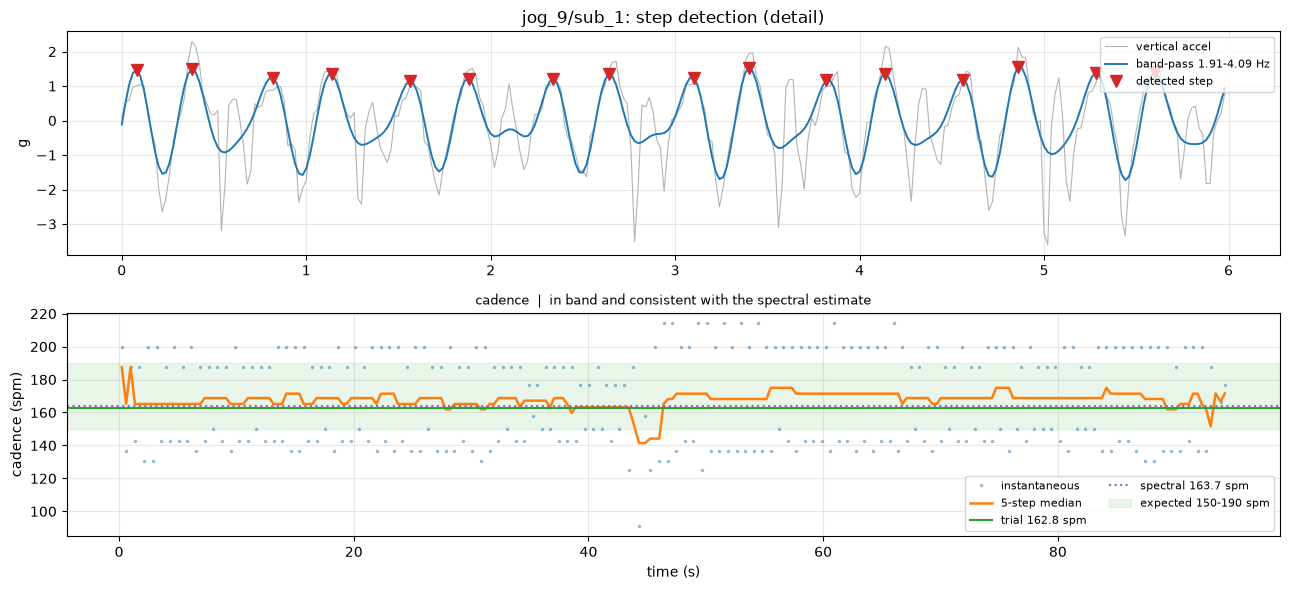

n_steps                                257
cadence_spm                            162.85
cadence_spm_median                     162.162
cadence_cv                             0.174
irregular_step_fraction                0.02
alternating_interval_asymmetry_pct     -32.231
span_s                                 94.32

cadence time series (steps per minute):


,t_s,cadence_spm,cadence_spm_smooth
0,0.23,200.000000,187.500000
1,0.60,136.363636,165.178571
2,0.98,187.500000,187.500000
3,1.35,142.857143,165.178571
4,1.72,187.500000,165.178571


In [15]:
fig = plotting.plot_steps(result)
plt.show()

cs = result["cadence_summary"]
for k, val in cs.items():
    print(f"{k:38s} {round(val, 3) if isinstance(val, float) else val}")
print()
print("cadence time series (steps per minute):")
result["cadence_series"].head()

### Validation across all 24 subjects

Cadence is validated against an **independent** estimator that shares no machinery with
peak detection: the spectral peak. If the two agree, the detector is doing its job and an
out-of-band number is a fact about the trial. If they disagree, the detector is at fault —
and the ratio between them says how (≈0.5 = missed alternate steps, ≈2.0 = harmonic
leakage).

In [16]:
table = pd.read_csv(REPO / "reports" / "pipeline_results.csv")
print(f"cadence {table['cadence_spm'].min():.1f}-{table['cadence_spm'].max():.1f} spm, "
      f"median {table['cadence_spm'].median():.1f}")
print(f"inside 150-190 spm: {int(table['cadence_in_band'].sum())}/{len(table)}")
print(f"detector/spectral ratio: {table['detector_spectral_ratio'].min():.3f} - "
      f"{table['detector_spectral_ratio'].max():.3f}")
print()
print("FLAGGED:")
table[table["cadence_flagged"]][["trial", "subject", "cadence_spm", "cadence_spm_spectral",
                                 "cadence_failure_cause", "cadence_diagnosis"]]

cadence 148.5-183.7 spm, median 164.7
inside 150-190 spm: 47/48
detector/spectral ratio: 0.961 - 1.041

FLAGGED:


,trial,subject,cadence_spm,cadence_spm_spectral,cadence_failure_cause,cadence_diagnosis
3,9,4,148.480795,148.882939,trial,detector agrees with the independent spectral ...


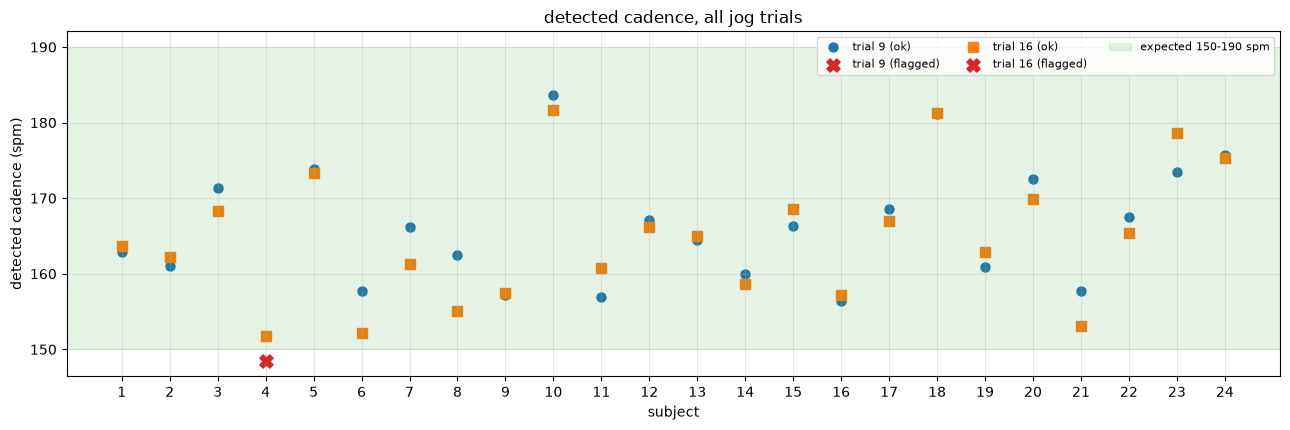

In [17]:
fig = plotting.plot_cadence_across_subjects(table)
plt.show()

### A cadence artifact that must not be mistaken for a gait metric

Instantaneous step intervals alternate short–long by up to ±30%. Real runners show 1–3%.
This is a **detector timing artifact**: when the two steps of a stride produce differently
shaped vertical waveforms, the crest of the band-passed fundamental shifts by a different
amount on alternate steps, so the timestamps alternate even when the runner's true step
times do not. The evidence is the correlation below with the amplitude-domain symmetry
index — the same underlying asymmetry driving both.

(It also means the cadence smoother must use an **even** window. An odd-length median sits
on one side of a period-2 alternation and sawtooths at exactly the rate it is meant to
suppress; `cadence_series` raises on an odd window rather than quietly doing that.)

In [18]:
r = np.corrcoef(table["alternating_interval_asymmetry_pct"].abs(),
                table["step_symmetry_index"])[0, 1]
print(f"alternating-interval asymmetry: {table['alternating_interval_asymmetry_pct'].min():.1f}% "
      f"to {table['alternating_interval_asymmetry_pct'].max():.1f}%")
print(f"corr(|interval asymmetry|, step symmetry index) = {r:.3f}")

alternating-interval asymmetry: -32.2% to 29.4%
corr(|interval asymmetry|, step symmetry index) = -0.908


---
## Stage 4 — left/right discrimination (EXPLORATORY)

**There is no ground truth in this dataset.** No left/right foot labels, and no record of
which trouser pocket held the phone. Nothing below is an accuracy measurement.

Theory under test: the pelvis rotates in opposite directions during left and right stance,
so the sign of angular velocity about the vertical axis at initial contact should separate
the sides.

The thing that makes this hard to evaluate honestly: alternation is nearly guaranteed by
signal structure alone. If ω_v carries strong power at the stride rate — half the step rate
— then sampling it once per step lands on alternating half-cycles *whatever its physical
origin and whatever its phase*. A pure sinusoid at f_step/2 sampled every 1/f_step
alternates perfectly while encoding nothing.

So we measure three controls that contain no left/right information by construction:
**random signs**, a **phase-randomised surrogate** (identical power spectrum, phase
destroyed), and a **mid-step control** (the real signal sampled halfway between steps,
where no contact occurs).

In [19]:
lat = result["lateral"]
print(f"labelled steps            {lat['n_labelled_steps']}")
print(f"contact window            {lat['contact_window_samples']} samples "
      f"= {1000 * lat['contact_window_s']:.0f} ms  <-- only ~{lat['contact_window_samples']} samples at {FS_HZ:g} Hz")
print(f"omega_v RMS               {lat['omega_v_rms_rad_s']:.2f} rad/s")
print(f"stride/step power ratio   {lat['stride_over_step_power']:.2f}")
print()
print(f"alternation at contact    {lat['alternation_consistency']:.3f}")
print(f"  random-sign null        {lat['null_random_mean']:.3f}")
print(f"  surrogate null          {lat['null_surrogate_mean']:.3f}")
print(f"  mid-step control        {lat['null_mid_step_rate']:.3f}")
print(f"  excess over surrogate   {lat['excess_over_surrogate']:+.3f}")
print()
print("labels (first 30):", "".join(lat["labels"][:30]))

labelled steps            257
contact window            5 samples = 100 ms  <-- only ~5 samples at 50 Hz
omega_v RMS               3.09 rad/s
stride/step power ratio   0.74

alternation at contact    0.539
  random-sign null        0.500
  surrogate null          0.547
  mid-step control        0.949
  excess over surrogate   -0.008

labels (first 30): BABBBAAAAAAABABBBABBBBAABABABA


### The result is dominated by sampling phase

Stage 3 delivers a step-rate phase *marker*, not a true initial contact. The theory names a
specific instant we cannot locate. Sweeping the sampling point across the whole step period
shows how much the headline number depends on that unknown offset.

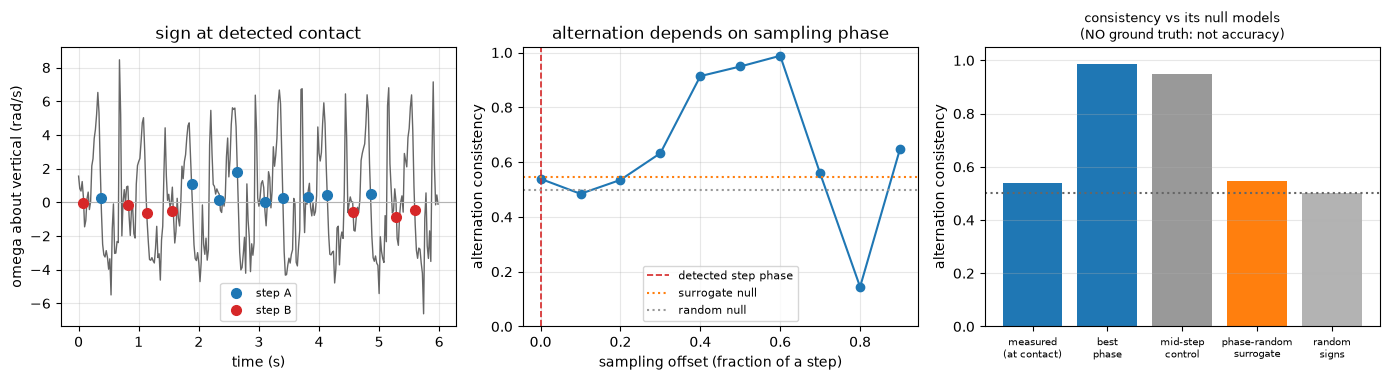

offset (fraction of a step): [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
alternation:                [0.539 0.484 0.535 0.633 0.914 0.949 0.988 0.559 0.145 0.648]

best 0.988 at offset 0.6   worst 0.145   range 0.844
max-over-phase surrogate null: mean 0.668, p95 0.749
best-phase result exceeds that p95: True


In [20]:
fig = plotting.plot_lateral(result)
plt.show()

sw = lat["phase_sweep"]
print("offset (fraction of a step):", np.round(sw["offsets_step_fraction"], 2))
print("alternation:               ", np.round(sw["alternation_by_offset"], 3))
print()
print(f"best {sw['best_alternation']:.3f} at offset {sw['best_offset_step_fraction']:.1f}   "
      f"worst {sw['worst_alternation']:.3f}   range {sw['alternation_range']:.3f}")
print(f"max-over-phase surrogate null: mean {lat['best_phase_surrogate_max_mean']:.3f}, "
      f"p95 {lat['best_phase_surrogate_max_p95']:.3f}")
print(f"best-phase result exceeds that p95: {lat['best_phase_beats_surrogate_p95']}")

The best-phase figure is a maximum over ten candidate offsets, so it is compared against a
null built the same way — sweep and maximise on each surrogate. Comparing a maximum to a
mean would be selection-biased: best-of-ten beats an average even when nothing is there.

### Across all 24 subjects

In [21]:
c = ["alternation_consistency", "alternation_surrogate_null", "excess_over_surrogate",
     "best_phase_alternation", "best_phase_surrogate_max_mean",
     "best_phase_excess_over_surrogate", "alternation_phase_range"]
print(table[c].describe(percentiles=[.05, .5, .95]).round(3).to_string())
print()
print(f"alternation >= 0.90 at detected contact:        "
      f"{int((table['alternation_consistency'] >= 0.90).sum())}/{len(table)}")
print(f"beats fixed-phase surrogate by > 0.10:          "
      f"{int((table['excess_over_surrogate'] > 0.10).sum())}/{len(table)}")
print(f"best-phase exceeds max-over-phase surrogate p95: "
      f"{int(table['best_phase_beats_surrogate_p95'].sum())}/{len(table)}")

       alternation_consistency  alternation_surrogate_null  excess_over_surrogate  best_phase_alternation  best_phase_surrogate_max_mean  best_phase_excess_over_surrogate  alternation_phase_range
count                   48.000                      48.000                 48.000                  48.000                         48.000                            48.000                   48.000
mean                     0.520                       0.571                 -0.051                   0.922                          0.726                             0.196                    0.776
std                      0.222                       0.086                  0.217                   0.095                          0.104                             0.091                    0.174
min                      0.091                       0.390                 -0.575                   0.592                          0.519                            -0.005                    0.350
5%                  

In [22]:
# Is the "best" sampling phase even reproducible within a subject?
po = table.pivot_table(index="subject", columns="trial", values="best_phase_offset")
agree = int((po[9] == po[16]).sum())
print(f"best-phase offset identical across a subject's two jog trials: {agree}/{len(po)}")
print()
print(table["best_phase_offset"].value_counts().sort_index().to_string())

best-phase offset identical across a subject's two jog trials: 9/24

best_phase_offset
0.0     4
0.1    15
0.2     9
0.3     6
0.5     5
0.6     4
0.7     2
0.9     3


**Stage 4 findings.**

1. At the detected contact, alternation is **at chance** (median 0.485) and sits *below*
   its own phase-randomised surrogate (median 0.561). As implemented against our best
   available contact proxy, the method does not work here.
2. Alternation swings from ~0.09 to ~1.00 across sampling phase *within a single trial*
   (median range 0.83). The headline number is a statement about sampling phase.
3. At the best phase, 40/48 trials exceed a properly constructed max-over-phase surrogate
   null, so there is *some* structure beyond the spectrum.
4. But the best phase is not reproducible: it agrees across a subject's own two jog trials
   for only 9/24 subjects. Structure that cannot be located twice in the same runner cannot
   be used.
5. **Consistency is not correctness.** A perfectly alternating sequence would be produced
   by a sensor encoding nothing about laterality, and we have no labels with which to tell
   the difference. Labels are deliberately `A`/`B`, never left/right — assigning sides also
   needs to know which pocket held the phone, which this dataset never recorded.

---
## Invariance checks — the claims, tested

"Placement- and rate-agnostic" is only worth stating if it is measured. Rotating every
sensor vector by an arbitrary rotation is exactly what a differently-oriented phone in the
same pocket produces; resampling tests whether anything hardcodes 50 Hz.

In [23]:
R = dsp.random_rotation_matrix(7)
rotated = pipeline.run_trial("jog", TRIAL, SUBJECT, fs_hz=FS_HZ)  # baseline
base_cad = rotated["cadence_summary"]["cadence_spm"]

seg2 = steps.steady_state_segment(np.linalg.norm(trial.user_accel @ R.T, axis=1), FS_HZ)
sl2 = slice(seg2["start"], seg2["stop"])
fr2 = orientation.build_frame(trial.user_accel[sl2] @ R.T, trial.gravity[sl2] @ R.T, FS_HZ)
av2 = orientation.vertical_component(trial.user_accel[sl2] @ R.T, trial.gravity[sl2] @ R.T)
f2 = steps.estimate_step_frequency(av2, FS_HZ)["f_step_hz"]
d2 = steps.detect_steps(av2, FS_HZ, f_step_hz=f2)
cad2 = steps.cadence_summary(d2["step_times_s"])["cadence_spm"]

print(f"cadence, original orientation : {base_cad:.9f} spm")
print(f"cadence, arbitrarily rotated  : {cad2:.9f} spm")
print(f"difference                    : {abs(cad2 - base_cad):.2e} spm")

cadence, original orientation : 162.849872774 spm
cadence, arbitrarily rotated  : 162.849872774 spm
difference                    : 0.00e+00 spm


In [24]:
inv = pd.read_csv(REPO / "reports" / "invariance.csv")
rot_cols = [c for c in inv.columns if c.endswith("_step_count_match")]
print(f"step count preserved in {int(inv[rot_cols].to_numpy().sum())}/{inv[rot_cols].size} rotated runs")
print(f"max cadence change under rotation: {inv['max_rotation_cadence_delta_spm'].max():.2e} spm")
print()
for fs in (25, 100, 200):
    col = f"rel_err_at_{fs}Hz"
    print(f"resampled to {fs:3d} Hz: median |cadence error| {100 * inv[col].median():.3f}%, "
          f"worst {100 * inv[col].max():.3f}%")

step count preserved in 144/144 rotated runs
max cadence change under rotation: 0.00e+00 spm

resampled to  25 Hz: median |cadence error| 0.047%, worst 0.513%
resampled to 100 Hz: median |cadence error| 0.034%, worst 0.435%
resampled to 200 Hz: median |cadence error| 0.049%, worst 0.787%


---
## Where this breaks when the sensor moves to the sacrum at 100–200 Hz

See `REPORT.md` for the full write-up. The short version, in the order it bites:

| Stage | Load-bearing dependency | What changes at sacrum / higher rate |
|---|---|---|
| 2 vertical | Tracking mode exists because the thigh swings ±15–30° | Sacrum tilt is far smaller; static frame becomes viable. Tracking still works, so this is safe |
| 2 forward | `step_band` beats broadband PCA 14.6 : 2.1 on conditioning **at the pocket** | Not validated at sacrum. Fore-aft should dominate more there, so PCA may become viable — re-measure, do not assume |
| 2 ML | Cross-check fails 46/48 here | Should *start passing* at sacrum. The check is the deliverable; keep it as a gate |
| 3 band | LP at 1.5 × f_step, tuned to pocket harmonic content | Sacrum harmonic structure differs; re-run the cutoff sweep. At 200 Hz this band throws away the impact transient you will want later |
| 3 timing | Detected peak is a phase marker, not contact | At 200 Hz the impact transient is resolvable and true contact becomes detectable — a different algorithm, not a tuned one |
| 4 all of it | Depends on contact timing we do not have, and on a phone on one thigh | Must be rebuilt from true contacts at sacrum. Nothing here transfers |